In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 1. Daten laden 
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

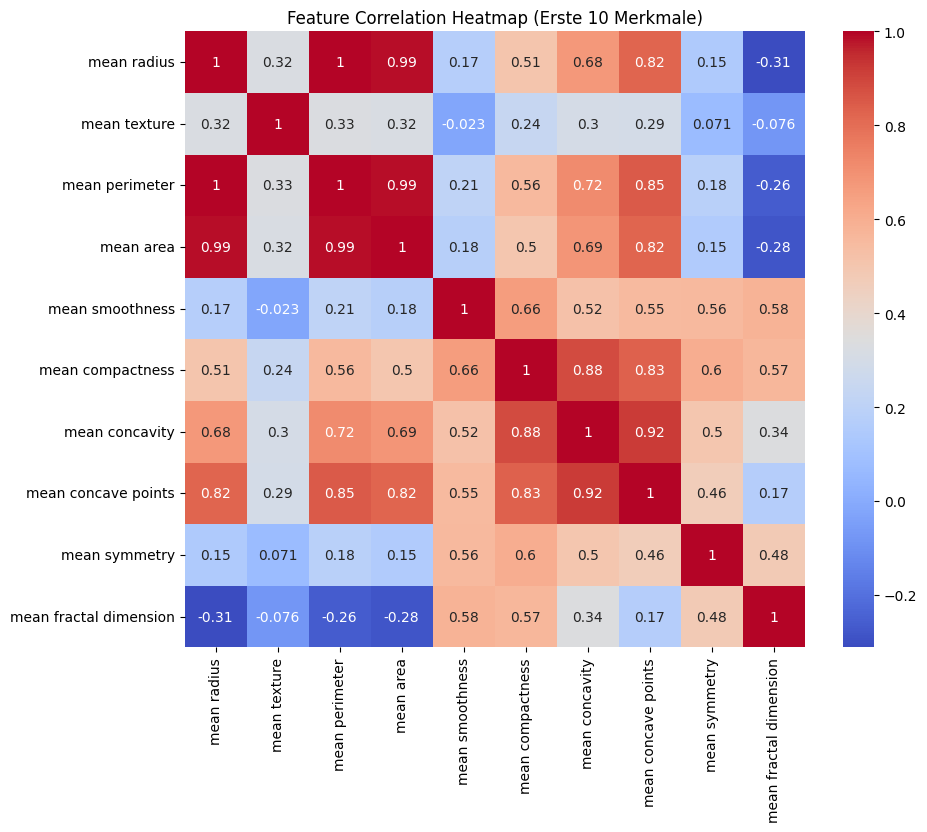

In [ ]:
# 2. Kurze explorative Analyse (EDA)
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :10].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap (Erste 10 Merkmale)')
plt.show()

In [4]:
# 3. Daten für das Modell vorbereiten
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# 4. Modell-Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# 5. Vorhersage und Evaluation
predictions = model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, predictions))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



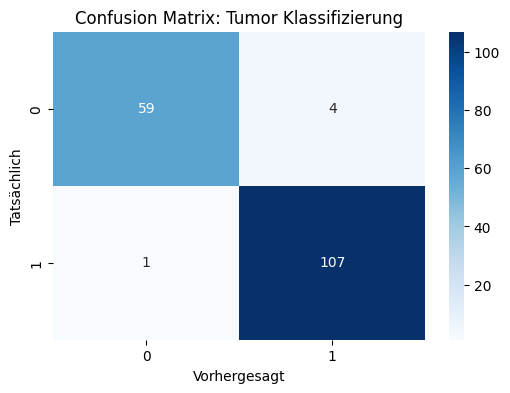

In [8]:
# 6. Confusion Matrix Visualisierung
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.title('Confusion Matrix: Tumor Klassifizierung')
plt.show()